In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


## Data loading

In [2]:
data_o_vib = pd.read_csv("data/Musical training and Pitch perception - O -_ Vib (respuestas) - Respuestas de formulario 1.csv")
data_vib_o = pd.read_csv("data/Musical training and Pitch perception - Vib -_ O - Respuestas de formulario 1.csv")

total_data = pd.concat([data_o_vib, data_vib_o], ignore_index=True)

total_data = total_data.set_axis(['temp',
       'MusicalTraining',
       'Instrument',
       'SkillProfeciency',
       'TrainingYears',
       'HighestMusicStudy',
       'PracticeNow',
       'RegularPractice', '(+)9 200 og',
       '(+)11 200 og', '(-)7 200 og', '(+)14 200 og', '(-)13 200 og',
       '(-)8 200 og', '(-)5 200 og', '(+)6 200 og', '(+)10 200 og',
       '(-)15 200 og', '(+)12 200 og', '(+)30 200 og', '(+)6 200 vib',
       '(-)13 200 vib', '(+)12 200 vib', '(+)30 200 vib', '(+)10 200 vib',
       '(-)15 200 vib', '(+)9 200 vib', '(-)7 200 vib', '(-)8 200 vib ',
       '(+)11 200 vib', '(-)5 200 vib', '(+)14 200 vib', '(-)5 400 og ',
       '(+)14 400 og', '(+)6 400 og', '(+)12 400 og', '(-)8 400 og',
       '(-)13 400 og', '(+)9 400 og', '(+)11 400 og', '(+)30 400 og',
       '(-)15 400 og', '(+)10 400 og', '(-)7 400 og', '(-)7 400 vib',
       '(+)11 400 vib', '(-)15 400 vib', '(-)8 400 vib', '(+)6 400 vib',
       '(-)13 400 vib', '(-)5 400 vib', '(+)9 400 vib', '(+)10 400 vib',
       '(+)12 400 vib', '(+)30 400 vib', '(+)14 400 vib', '(+)9 1200 og',
       '(-)15 1200 og', '(+)14 1200 og', '(+)10 1200 og', '(+)12 1200 og',
       '(+)6 1200 og', '(-)5 1200 og', '(+)30 1200 og', '(+)11 1200 og',
       '(-)8 1200 og', '(-)7 1200 og', '(-)13 1200 og', '(-)13 1200 vib',
       '(+)14 1200 vib', '(+)12 1200 vib', '(+)9 1200 vib', '(-)15 1200 vib',
       '(-)5 1200 vib', '(-)7 1200 vib', '(+)30 1200 vib', '(+)11 1200 vib',
       '(+)10 1200 vib', '(+)6 1200 vib', '(-)8 1200 vib'], axis=1)

total_data["Instrument"] = total_data["Instrument"].fillna("None")
total_data["HighestMusicStudy"] = total_data["HighestMusicStudy"].fillna("None")

In [3]:
display(data_o_vib.head())
display(data_vib_o.head())
display(total_data.head())

,Marca temporal,"Do you have any musical training (musician, producer, recorder...)?","If so, which instrument do you play/are you familiar with or what kind of training do you have?",How would you rate your skill on your primary instrument?,How many years of formal music training have you had?,What is the highest level of music theory you have studied?,Do you still practice music nowadays?,"If so, how often do you practice music?",(+)9 200 og,(+)11 200 og,...,(+)12 1200 vib,(+)9 1200 vib,(-)15 1200 vib,(-)5 1200 vib,(-)7 1200 vib,(+)30 1200 vib,(+)11 1200 vib,(+)10 1200 vib,(+)6 1200 vib,(-)8 1200 vib
0,21/01/2026 10:56:18,Yes,clarinet,Beginner,4-6 years,"Basic (e.g., notes, rhythms)",Yes,Rarely,Equal,Equal,...,Acending,Acending,Descending,Equal,Descending,Acending,Acending,Acending,Acending,Equal
1,21/01/2026 11:28:43,No,NaN,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Equal,Equal,Descending,Descending,Equal,Acending,Acending,Equal,Equal,Equal
2,21/01/2026 13:08:31,No,NaN,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
3,21/01/2026 13:08:31,Not sure,piano,Beginner,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
4,21/01/2026 14:56:12,Yes,piano,Intermediate,4-6 years,"Intermediate (e.g., key signatures, harmony)",Yes,A few times a week,Equal,Acending,...,Acending,Acending,Equal,Equal,Equal,Acending,Acending,Equal,Acending,Descending


,Marca temporal,"Do you have any musical training (musician, producer, recorder...)?","If so, which instrument do you play/are you familiar with or what kind of training do you have?",How would you rate your skill on your primary instrument?,How many years of formal music training have you had?,What is the highest level of music theory you have studied?,Do you still practice music nowadays?,"If so, how often do you practice music?",(+)6 200 vib,(-)13 200 vib,...,(+)14 1200 og,(+)10 1200 og,(+)12 1200 og,(+)6 1200 og,(-)5 1200 og,(+)30 1200 og,(+)11 1200 og,(-)8 1200 og,(-)7 1200 og,(-)13 1200 og
0,21/01/2026 11:18:33,Yes,guitar,Advanced,1-3 years,NaN,Yes,Daily,Descending,Equal,...,Acending,Acending,Acending,Acending,Descending,Acending,Acending,Descending,Descending,Descending
1,21/01/2026 13:36:32,Yes,piano,Advanced,10+ years,"Advanced (e.g., counterpoint, analysis)",Yes,Daily,Equal,Equal,...,Acending,Acending,Acending,Equal,Equal,Acending,Acending,Equal,Acending,Descending
2,21/01/2026 15:52:05,Yes,voice/ production,Intermediate,7-9 years,"Basic (e.g., notes, rhythms)",Yes,A few times a month,Equal,Descending,...,Acending,Acending,Acending,Equal,Equal,Acending,Equal,Descending,Equal,Descending
3,21/01/2026 18:45:19,Yes,piano,Beginner,4-6 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Equal,Equal,Equal,Descending,Descending,Acending,Acending,Descending,Descending,Descending
4,21/01/2026 18:54:06,No,NaN,I don't play any instrument,0 years,NaN,Yes,A few times a week,Equal,Equal,...,Descending,Acending,Acending,Equal,Equal,Acending,Equal,Descending,Equal,Equal


,temp,MusicalTraining,Instrument,SkillProfeciency,TrainingYears,HighestMusicStudy,PracticeNow,RegularPractice,(+)9 200 og,(+)11 200 og,...,(+)12 1200 vib,(+)9 1200 vib,(-)15 1200 vib,(-)5 1200 vib,(-)7 1200 vib,(+)30 1200 vib,(+)11 1200 vib,(+)10 1200 vib,(+)6 1200 vib,(-)8 1200 vib
0,21/01/2026 10:56:18,Yes,clarinet,Beginner,4-6 years,"Basic (e.g., notes, rhythms)",Yes,Rarely,Equal,Equal,...,Acending,Acending,Descending,Equal,Descending,Acending,Acending,Acending,Acending,Equal
1,21/01/2026 11:28:43,No,None,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Equal,Equal,Descending,Descending,Equal,Acending,Acending,Equal,Equal,Equal
2,21/01/2026 13:08:31,No,None,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
3,21/01/2026 13:08:31,Not sure,piano,Beginner,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
4,21/01/2026 14:56:12,Yes,piano,Intermediate,4-6 years,"Intermediate (e.g., key signatures, harmony)",Yes,A few times a week,Equal,Acending,...,Acending,Acending,Equal,Equal,Equal,Acending,Acending,Equal,Acending,Descending


## General statistics of our population

In [4]:
print(f"Number of participants with steady first: {data_o_vib.shape[0]}")
print(f"Number of participants with vibrato first: {data_vib_o.shape[0]}")
print(f"Total number of participants: {total_data.shape[0]}")

Number of participants with steady first: 24
Number of participants with vibrato first: 19
Total number of participants: 43


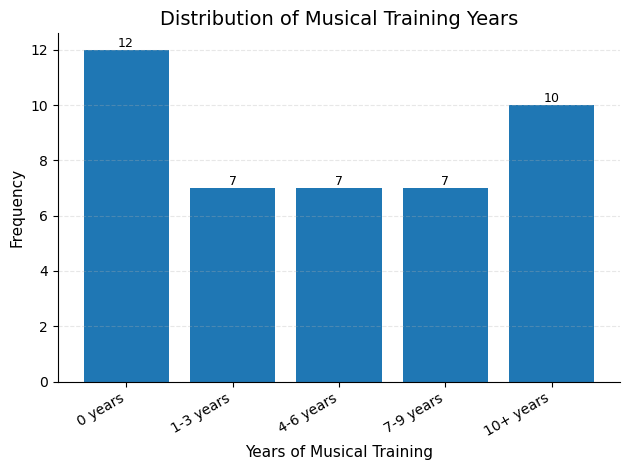

In [5]:

musical_training_years = total_data["TrainingYears"]

# Desired order
order = ["0 years", "1-3 years", "4-6 years", "7-9 years", "10+ years"]

# Count and reorder
counts = musical_training_years.value_counts().reindex(order)

plt.figure()

bars = plt.bar(counts.index, counts.values)

# Title and labels
plt.title("Distribution of Musical Training Years", fontsize=14)
plt.xlabel("Years of Musical Training", fontsize=11)
plt.ylabel("Frequency", fontsize=11)

# Rotate x labels
plt.xticks(rotation=30, ha="right")

# Light grid
plt.grid(axis="y", alpha=0.3, linestyle="--")

# Remove top/right spines for cleaner look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [6]:
total_data.head()

,temp,MusicalTraining,Instrument,SkillProfeciency,TrainingYears,HighestMusicStudy,PracticeNow,RegularPractice,(+)9 200 og,(+)11 200 og,...,(+)12 1200 vib,(+)9 1200 vib,(-)15 1200 vib,(-)5 1200 vib,(-)7 1200 vib,(+)30 1200 vib,(+)11 1200 vib,(+)10 1200 vib,(+)6 1200 vib,(-)8 1200 vib
0,21/01/2026 10:56:18,Yes,clarinet,Beginner,4-6 years,"Basic (e.g., notes, rhythms)",Yes,Rarely,Equal,Equal,...,Acending,Acending,Descending,Equal,Descending,Acending,Acending,Acending,Acending,Equal
1,21/01/2026 11:28:43,No,None,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Equal,Equal,Descending,Descending,Equal,Acending,Acending,Equal,Equal,Equal
2,21/01/2026 13:08:31,No,None,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
3,21/01/2026 13:08:31,Not sure,piano,Beginner,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
4,21/01/2026 14:56:12,Yes,piano,Intermediate,4-6 years,"Intermediate (e.g., key signatures, harmony)",Yes,A few times a week,Equal,Acending,...,Acending,Acending,Equal,Equal,Equal,Acending,Acending,Equal,Acending,Descending


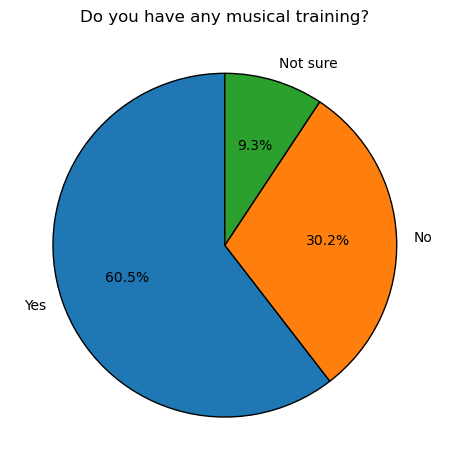

In [7]:
instrument_distribution = total_data["MusicalTraining"]

# Count and reorder
counts = instrument_distribution.value_counts()

plt.figure()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
        wedgeprops={'edgecolor': 'black'}
)

plt.title("Do you have any musical training?")

plt.tight_layout()
plt.show()

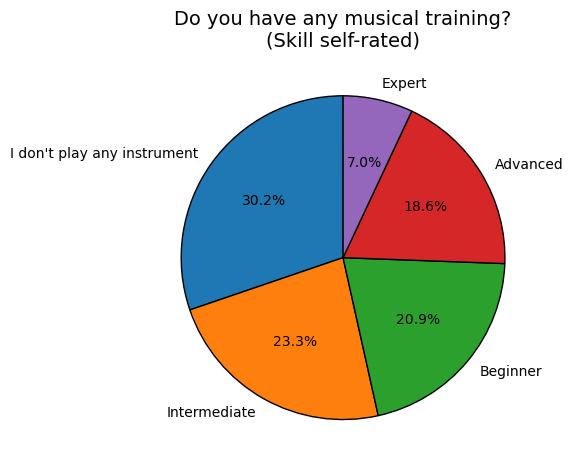

In [8]:
skill_proficieny = total_data["SkillProfeciency"]

# Count and reorder
counts = skill_proficieny.value_counts()

plt.figure()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
        wedgeprops={'edgecolor': 'black'}
)

plt.title("Do you have any musical training?\n(Skill self-rated)",fontsize=14)

plt.tight_layout()
plt.show()

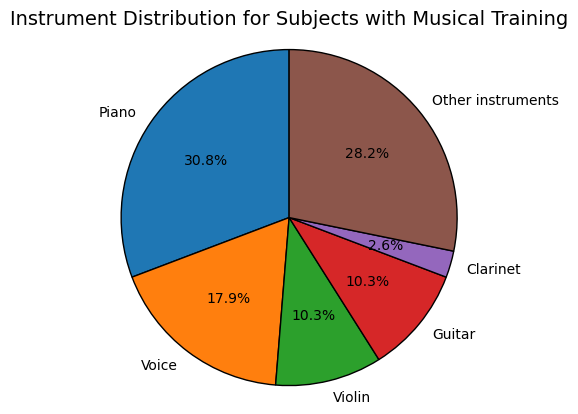

In [9]:
instruments = (
    total_data[total_data['MusicalTraining'].isin(['Yes'])]["Instrument"]
    .str.lower()
    .str.split("/")
)

exploded = instruments.explode().str.strip()

counts = exploded.value_counts()


top_n = 5
top_counts = counts[:top_n]
other_sum = counts[top_n:].sum()

final_counts = pd.concat([
    top_counts,
    pd.Series({"Other instruments": other_sum})
])

plt.figure()

plt.pie(
    final_counts.values,
    labels=final_counts.index.str.capitalize(),
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
plt.axis('equal')  # Makes it a perfect circle


plt.axis("equal")
plt.title("Instrument Distribution for Subjects with Musical Training",fontsize=14)
plt.show()

## JND-related results

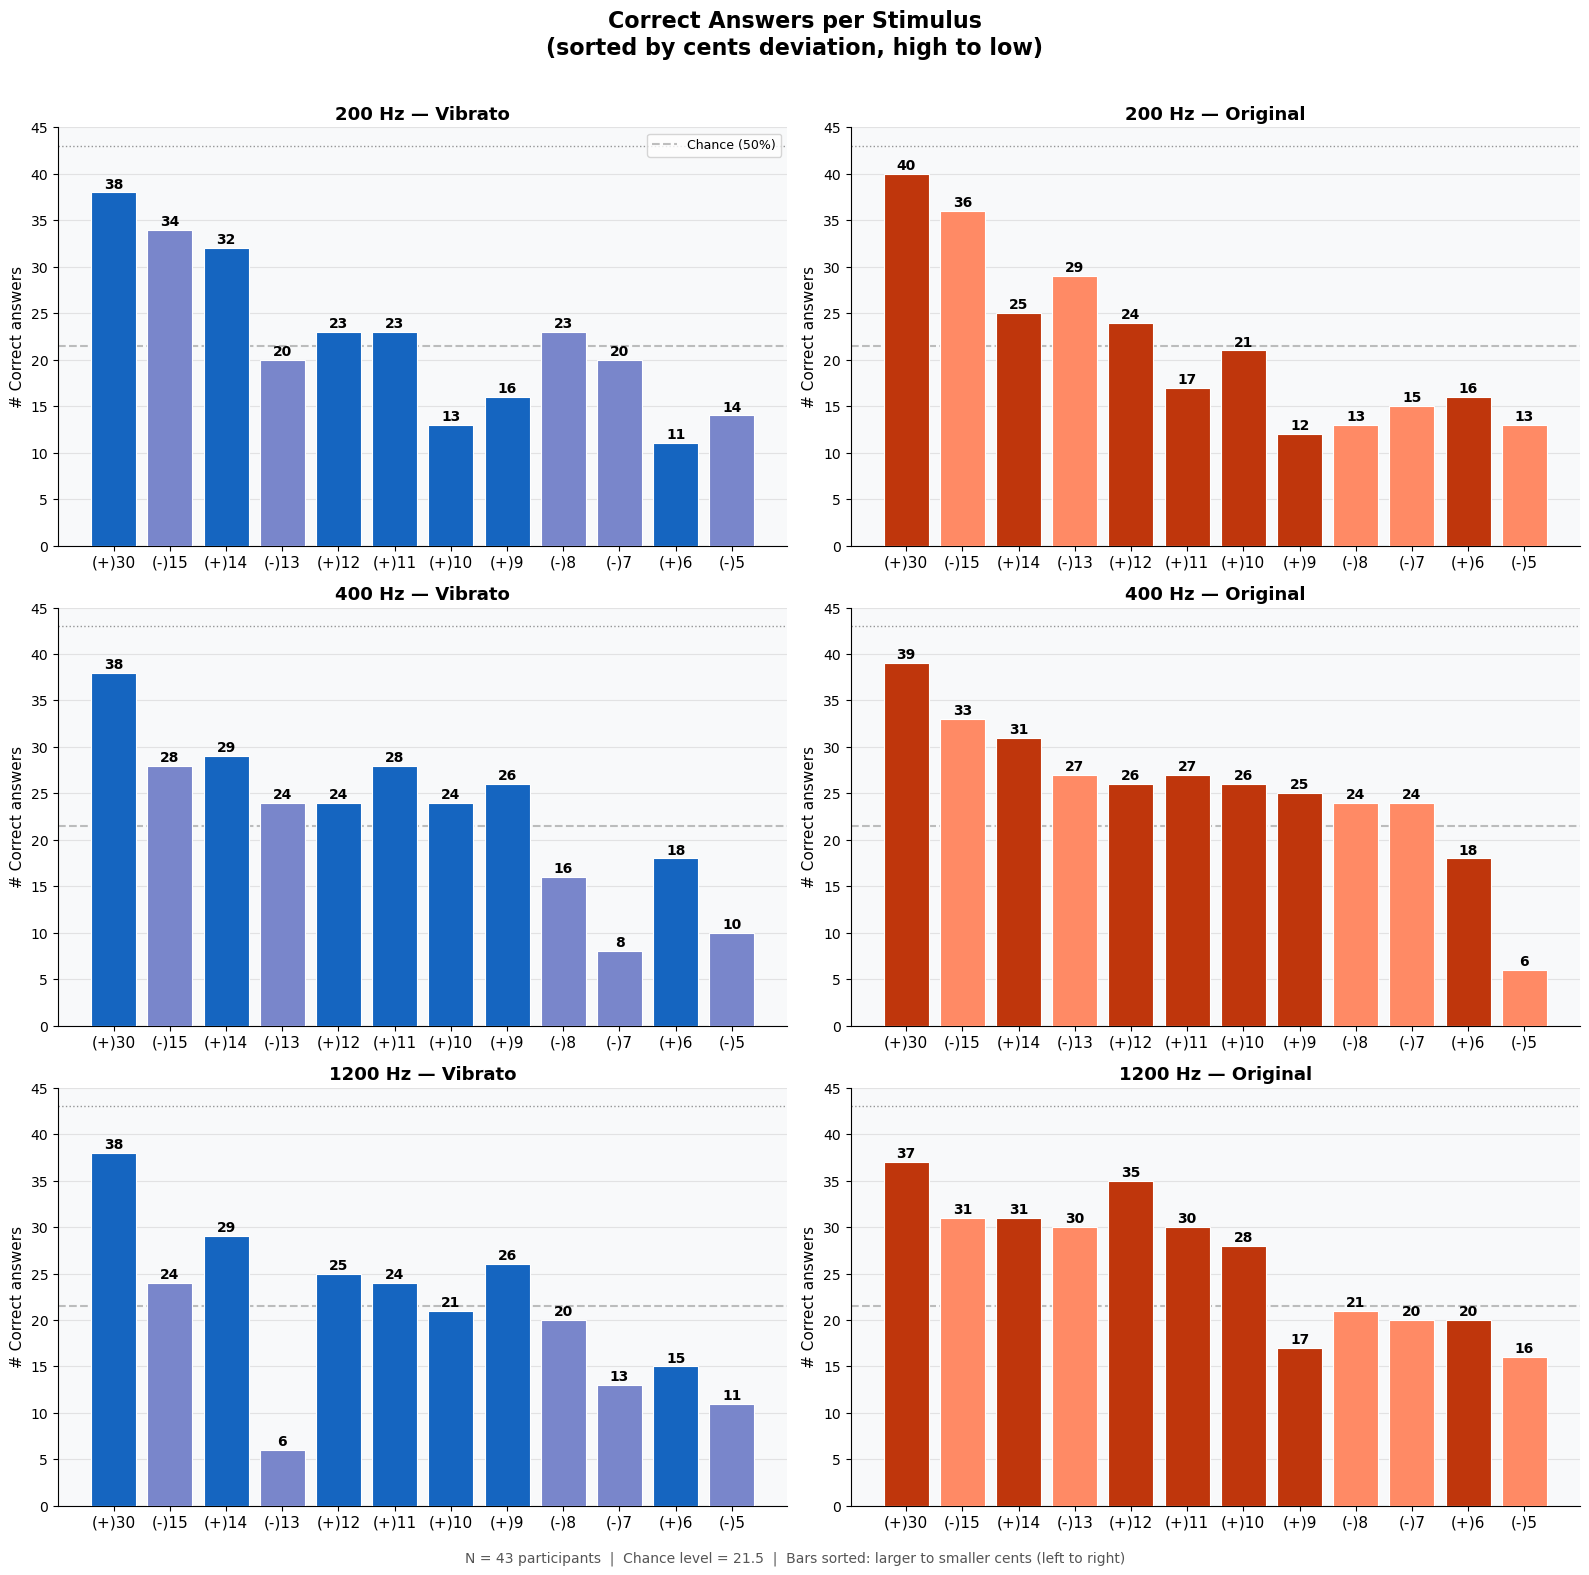

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ── 2. Identify stimulus columns (everything after the first 8 metadata cols) ─
total_stim_cols = total_data.columns[8:]
n_participants = len(total_data)

# ── 3. Parse each stimulus column and count correct answers ───────────────────
results = []
for col in total_stim_cols:
    col_stripped = col.strip()
    sign = '+' if col_stripped.startswith('(+)') else '-'
    parts = col_stripped.replace('(+)', '').replace('(-)', '').strip().split()
    cents = int(parts[0])
    freq  = int(parts[1])
    typ   = parts[2]   # 'vib' or 'og'

    # Correct answer: Ascending for (+), Descending for (-)
    if sign == '+':
        correct = (total_data[col] == 'Acending').sum()
    else:
        correct = (total_data[col] == 'Descending').sum()

    signed_cents = cents if sign == '+' else -cents
    label = f"(+){cents}" if sign == '+' else f"(-){cents}"
    results.append({
        'sign': sign, 'cents': cents, 'signed_cents': signed_cents,
        'freq': freq, 'type': typ, 'correct': correct, 'label': label
    })

res_df = pd.DataFrame(results)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
freqs        = [200, 400, 1200]
types_labels = {'vib': 'Vibrato', 'og': 'Original'}

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle(
    'Correct Answers per Stimulus\n(sorted by cents deviation, high to low)',
    fontsize=16, fontweight='bold', y=0.98
)

for row_idx, freq in enumerate(freqs):
    for col_idx, typ in enumerate(['vib', 'og']):
        ax = axes[row_idx, col_idx]

        subset = res_df[(res_df['freq'] == freq) & (res_df['type'] == typ)].copy()
        # Sort from bigger to smaller cents (positive first, then negative)
        subset = subset.sort_values('cents', ascending=False)

        x_labels = subset['label'].tolist()
        y_vals   = subset['correct'].tolist()
        signed   = subset['signed_cents'].tolist()

        # Darker shade for positive cents, lighter for negative
        pos_color = '#1565C0' if typ == 'vib' else '#BF360C'
        neg_color = '#7986CB' if typ == 'vib' else '#FF8A65'
        bar_colors = [pos_color if s > 0 else neg_color for s in signed]

        bars = ax.bar(
            range(len(x_labels)), y_vals,
            color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3
        )

        # Value labels on top of each bar
        for bar, val in zip(bars, y_vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold'
            )

        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, fontsize=11)
        ax.set_ylim(0, n_participants + 2)
        ax.set_ylabel('# Correct answers', fontsize=11)
        ax.set_title(f'{freq} Hz — {types_labels[typ]}', fontsize=13, fontweight='bold')

        # Chance level line
        ax.axhline(y=n_participants / 2, color='gray', linestyle='--',
                   alpha=0.5, label='Chance (50%)', zorder=2)
        ax.axhline(y=n_participants, color='black', linestyle=':',
                   alpha=0.4, linewidth=1, zorder=2)

        ax.set_facecolor('#F8F9FA')
        ax.grid(axis='y', alpha=0.3, zorder=1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=9)

fig.text(
    0.5, 0.01,
    f'N = {n_participants} participants  |  Chance level = {n_participants / 2:.1f}'
    f'  |  Bars sorted: larger to smaller cents (left to right)',
    ha='center', fontsize=10, color='#555555'
)

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()

### Accuracy By Instrument

In [12]:
acc_by_instrument = total_data.drop(columns=['MusicalTraining','SkillProfeciency','TrainingYears','HighestMusicStudy','PracticeNow','RegularPractice'])

In [13]:
acc_by_instrument.head()

,temp,Instrument,(+)9 200 og,(+)11 200 og,(-)7 200 og,(+)14 200 og,(-)13 200 og,(-)8 200 og,(-)5 200 og,(+)6 200 og,...,(+)12 1200 vib,(+)9 1200 vib,(-)15 1200 vib,(-)5 1200 vib,(-)7 1200 vib,(+)30 1200 vib,(+)11 1200 vib,(+)10 1200 vib,(+)6 1200 vib,(-)8 1200 vib
0,21/01/2026 10:56:18,clarinet,Equal,Equal,Descending,Acending,Equal,Descending,Equal,Descending,...,Acending,Acending,Descending,Equal,Descending,Acending,Acending,Acending,Acending,Equal
1,21/01/2026 11:28:43,None,Equal,Equal,Equal,Equal,Equal,Equal,Equal,Equal,...,Equal,Equal,Descending,Descending,Equal,Acending,Acending,Equal,Equal,Equal
2,21/01/2026 13:08:31,None,Equal,Equal,Equal,Equal,Equal,Equal,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
3,21/01/2026 13:08:31,piano,Equal,Equal,Equal,Equal,Equal,Equal,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
4,21/01/2026 14:56:12,piano,Equal,Acending,Equal,Acending,Descending,Acending,Acending,Acending,...,Acending,Acending,Equal,Equal,Equal,Acending,Acending,Equal,Acending,Descending


In [14]:
# Performance metrics per subject based on stimulus columns
acc_cols = [c for c in acc_by_instrument.columns if c.startswith("(+)") or c.startswith("(-)")]

def _expected_from_col(col_name: str) -> str:
    return "Acending" if col_name.strip().startswith("(+)") else "Descending"

def _mean_correct(row, cols):
    if not cols:
        return np.nan
    correct = [(row[c] == _expected_from_col(c)) for c in cols]
    return np.mean(correct) * 100

# Column groups
og_pos_cols = [c for c in acc_cols if c.startswith("(+)") and c.strip().endswith("og")]
og_neg_cols = [c for c in acc_cols if c.startswith("(-)") and c.strip().endswith("og")]
vib_pos_cols = [c for c in acc_cols if c.startswith("(+)") and c.strip().endswith("vib")]
vib_neg_cols = [c for c in acc_cols if c.startswith("(-)") and c.strip().endswith("vib")]
og_cols = [c for c in acc_cols if c.strip().endswith("og")]
vib_cols = [c for c in acc_cols if c.strip().endswith("vib")]
pos_cols = [c for c in acc_cols if c.startswith("(+)")]
neg_cols = [c for c in acc_cols if c.startswith("(-)")]

# Compute performance per subject
performance_by_subject = acc_by_instrument.copy()
performance_by_subject["Accuracy_General"] = performance_by_subject.apply(lambda r: _mean_correct(r, acc_cols), axis=1)
performance_by_subject["Accuracy_OG_General"] = performance_by_subject.apply(lambda r: _mean_correct(r, og_cols), axis=1)
performance_by_subject["Accuracy_VIB_General"] = performance_by_subject.apply(lambda r: _mean_correct(r, vib_cols), axis=1)
performance_by_subject["Accuracy_OG_Positive"] = performance_by_subject.apply(lambda r: _mean_correct(r, og_pos_cols), axis=1)
performance_by_subject["Accuracy_OG_Negative"] = performance_by_subject.apply(lambda r: _mean_correct(r, og_neg_cols), axis=1)
performance_by_subject["Accuracy_VIB_Positive"] = performance_by_subject.apply(lambda r: _mean_correct(r, vib_pos_cols), axis=1)
performance_by_subject["Accuracy_VIB_Negative"] = performance_by_subject.apply(lambda r: _mean_correct(r, vib_neg_cols), axis=1)
performance_by_subject["Accuracy_Positive_General"] = performance_by_subject.apply(lambda r: _mean_correct(r, pos_cols), axis=1)
performance_by_subject["Accuracy_Negative_General"] = performance_by_subject.apply(lambda r: _mean_correct(r, neg_cols), axis=1)

performance_by_subject[[
    "Accuracy_General",
    "Accuracy_OG_General",
    "Accuracy_VIB_General",
    "Accuracy_OG_Positive",
    "Accuracy_OG_Negative",
    "Accuracy_VIB_Positive",
    "Accuracy_VIB_Negative",
    "Accuracy_Positive_General",
    "Accuracy_Negative_General"
 ]].head()

,Accuracy_General,Accuracy_OG_General,Accuracy_VIB_General,Accuracy_OG_Positive,Accuracy_OG_Negative,Accuracy_VIB_Positive,Accuracy_VIB_Negative,Accuracy_Positive_General,Accuracy_Negative_General
0,73.611111,72.222222,75.000000,71.428571,73.333333,85.714286,60.000000,78.571429,66.666667
1,33.333333,27.777778,38.888889,33.333333,20.000000,38.095238,40.000000,35.714286,30.000000
2,54.166667,44.444444,63.888889,38.095238,53.333333,61.904762,66.666667,50.000000,60.000000
3,52.777778,38.888889,66.666667,28.571429,53.333333,66.666667,66.666667,47.619048,60.000000
4,69.444444,72.222222,66.666667,90.476190,46.666667,80.952381,46.666667,85.714286,46.666667


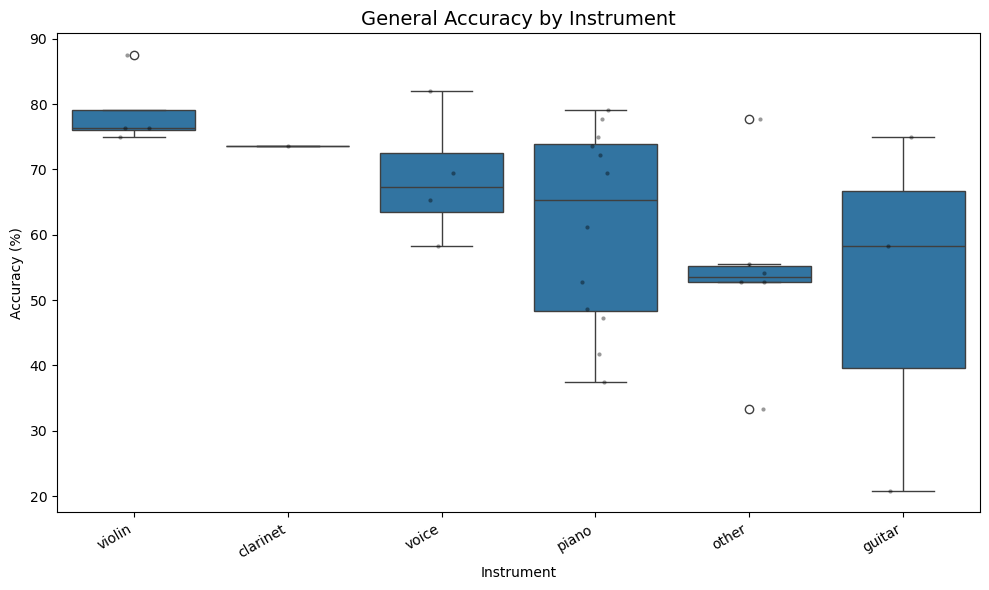

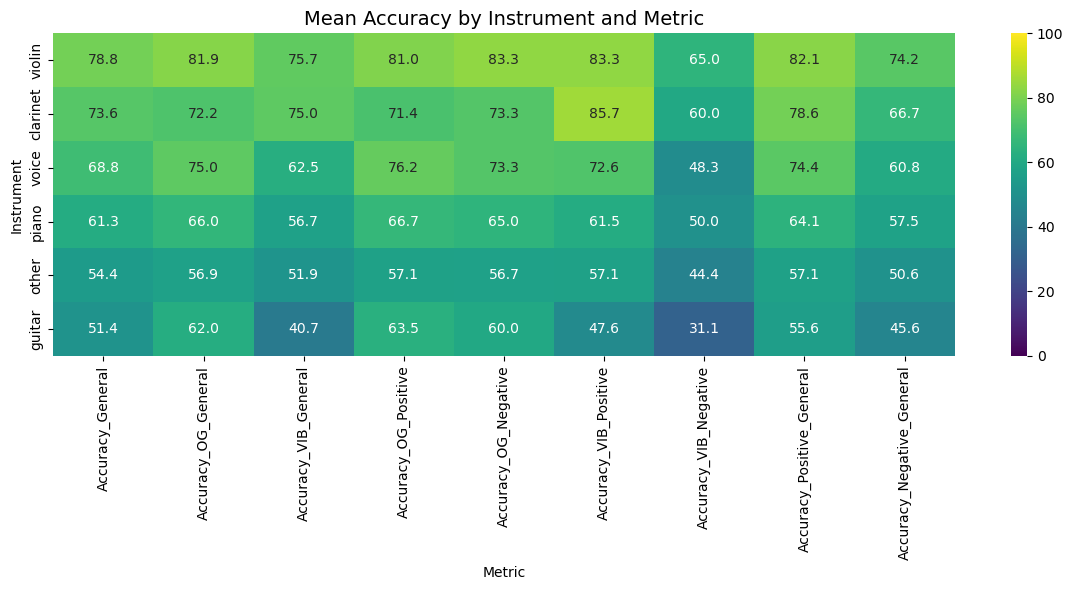

In [26]:
import seaborn as sns

# Metrics to visualize
perf_cols = [
    "Accuracy_General",
    "Accuracy_OG_General",
    "Accuracy_VIB_General",
    "Accuracy_OG_Positive",
    "Accuracy_OG_Negative",
    "Accuracy_VIB_Positive",
    "Accuracy_VIB_Negative",
    "Accuracy_Positive_General",
    "Accuracy_Negative_General",
]

# Prepare instrument labels
perf_instr = performance_by_subject.copy()
perf_instr["Instrument_primary"] = (
    perf_instr["Instrument"]
    .fillna("none")
    .str.lower()
    .str.split("/")
    .str[0]
    .str.strip()
)

# Keep top instruments, group the rest as Other
top_n = 6
top_instruments = perf_instr["Instrument_primary"].value_counts().head(top_n).index
perf_instr["Instrument_group"] = perf_instr["Instrument_primary"].where(
    perf_instr["Instrument_primary"].isin(top_instruments), "other"
)

# Optional: remove non-instrument responses
perf_instr = perf_instr[perf_instr["Instrument_group"] != "none"]

# 1) Boxplot: General accuracy by instrument
order = (
    perf_instr.groupby("Instrument_group")["Accuracy_General"]
    .mean()
    .sort_values(ascending=False)
    .index
)
plt.figure(figsize=(10, 6))
sns.boxplot(data=perf_instr, x="Instrument_group", y="Accuracy_General", order=order)
sns.stripplot(
    data=perf_instr, x="Instrument_group", y="Accuracy_General",
    order=order, color="black", size=3, alpha=0.4
 )
plt.title("General Accuracy by Instrument", fontsize=14)
plt.xlabel("Instrument")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 2) Heatmap: Mean accuracy by instrument across metrics
mean_table = (
    perf_instr.groupby("Instrument_group")[perf_cols]
    .mean()
    .sort_values(by="Accuracy_General", ascending=False)
)
plt.figure(figsize=(12, 6))
sns.heatmap(mean_table, annot=True, fmt=".1f", cmap="viridis", vmin=0, vmax=100)
plt.title("Mean Accuracy by Instrument and Metric", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Instrument")
plt.tight_layout()
plt.show()

In [ ]:
# Statistical tests: Compare vibrato vs steady tones (paired)
print("=" * 60)
print("STATISTICAL TESTS: VIBRATO VS STEADY TONES (PAIRED)")
print("=" * 60)

paired = pd.concat([
    perf_instr["Accuracy_OG_General"].astype(float),
    perf_instr["Accuracy_VIB_General"].astype(float)
], axis=1).dropna()
paired.columns = ["OG", "VIB"]

og = paired["OG"]
vib = paired["VIB"]

# Paired t-test
t_stat, p_value = stats.ttest_rel(og, vib)
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# Wilcoxon signed-rank test (non-parametric alternative)
w_stat, w_p_value = stats.wilcoxon(og, vib, zero_method='wilcox', correction=False, alternative='two-sided', mode='approx')
print(f"\nWilcoxon signed-rank test:")
print(f"  W-statistic: {w_stat:.4f}")
print(f"  p-value: {w_p_value:.4f}")

# Effect size (Cohen's dz for paired samples)
diff = og - vib
dz = diff.mean() / diff.std(ddof=1)
print(f"\nEffect size (Cohen's dz): {dz:.4f}")

STATISTICAL TESTS: VIBRATO VS STEADY TONES

Independent t-test:
  t-statistic: 1.9334
  p-value: 0.0581
  Significant at α=0.05: No

Mann-Whitney U test (non-parametric):
  U-statistic: 569.5000
  p-value: 0.0780


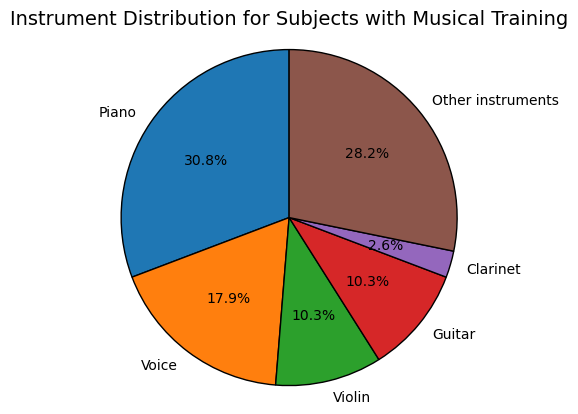

In [28]:
instruments = (
    total_data[total_data['MusicalTraining'].isin(['Yes'])]["Instrument"]
    .str.lower()
    .str.split("/")
)

exploded = instruments.explode().str.strip()

counts = exploded.value_counts()


top_n = 5
top_counts = counts[:top_n]
other_sum = counts[top_n:].sum()

final_counts = pd.concat([
    top_counts,
    pd.Series({"Other instruments": other_sum})
])

plt.figure()

plt.pie(
    final_counts.values,
    labels=final_counts.index.str.capitalize(),
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
plt.axis('equal')  # Makes it a perfect circle


plt.axis("equal")
plt.title("Instrument Distribution for Subjects with Musical Training",fontsize=14)
plt.show()

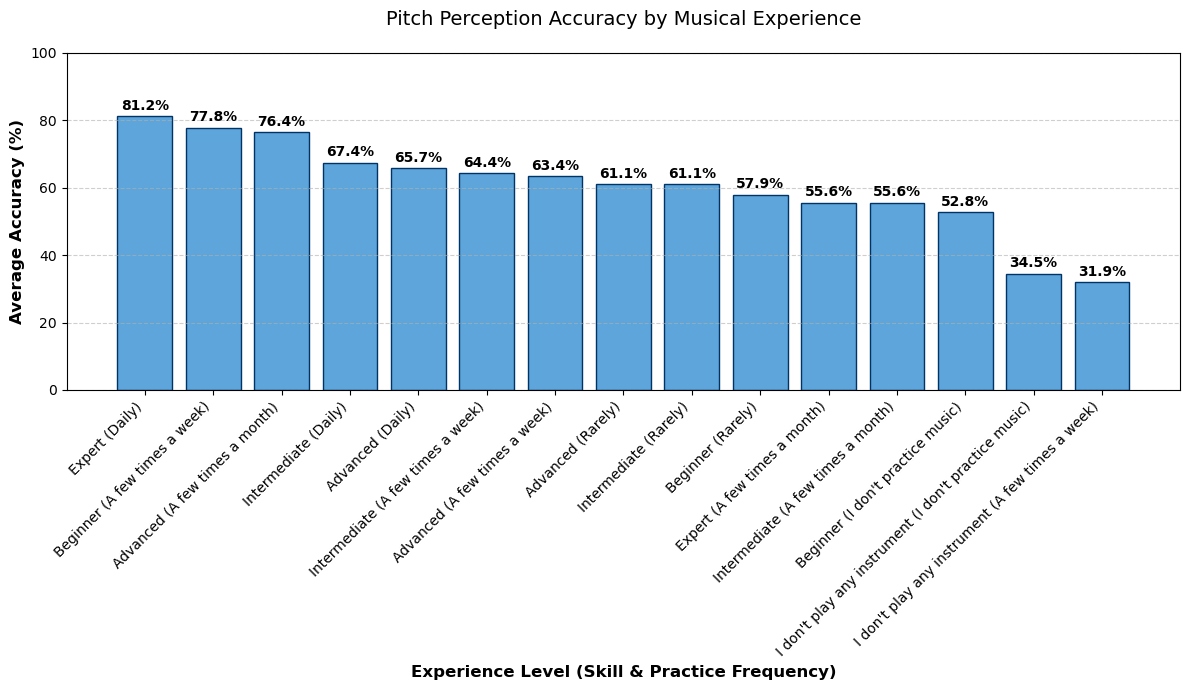

In [29]:
# These represent the pitch change tests (Positive = Ascending, Negative = Descending)
test_cols = [c for c in total_data.columns if c.startswith("(+)") or c.startswith("(-)")]

# 3. Define the accuracy calculation function
def calculate_accuracy(row):
    correct = 0
    total = len(test_cols)
    for col in test_cols:
        # Determine ground truth from the column name
        # Note: Matching the spelling 'Acending' found in the dataset
        expected = "Acending" if col.startswith("(+)") else "Descending"
        if row[col] == expected:
            correct += 1
    return (correct / total) * 100

# Apply accuracy calculation to each participant
total_data['Accuracy'] = total_data.apply(calculate_accuracy, axis=1)

# 4. Create the composite grouping: Skill Level + Practice Frequency
skill_col = "SkillProfeciency"
practice_col = "RegularPractice"
total_data['Group'] = total_data[skill_col].str.strip() + " (" + total_data[practice_col].str.strip() + ")"

# 5. Aggregate average accuracy by Group
grouped_data = total_data.groupby('Group')['Accuracy'].mean().sort_values(ascending=False).reset_index()

# 6. Plot the results
plt.figure(figsize=(12, 7))
bars = plt.bar(grouped_data['Group'], grouped_data['Accuracy'], color='#5da5da', edgecolor='#003366')

plt.xlabel('Experience Level (Skill & Practice Frequency)', fontsize=12, fontweight='bold')
plt.ylabel('Average Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Pitch Perception Accuracy by Musical Experience', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_by_experience.png')
plt.show()

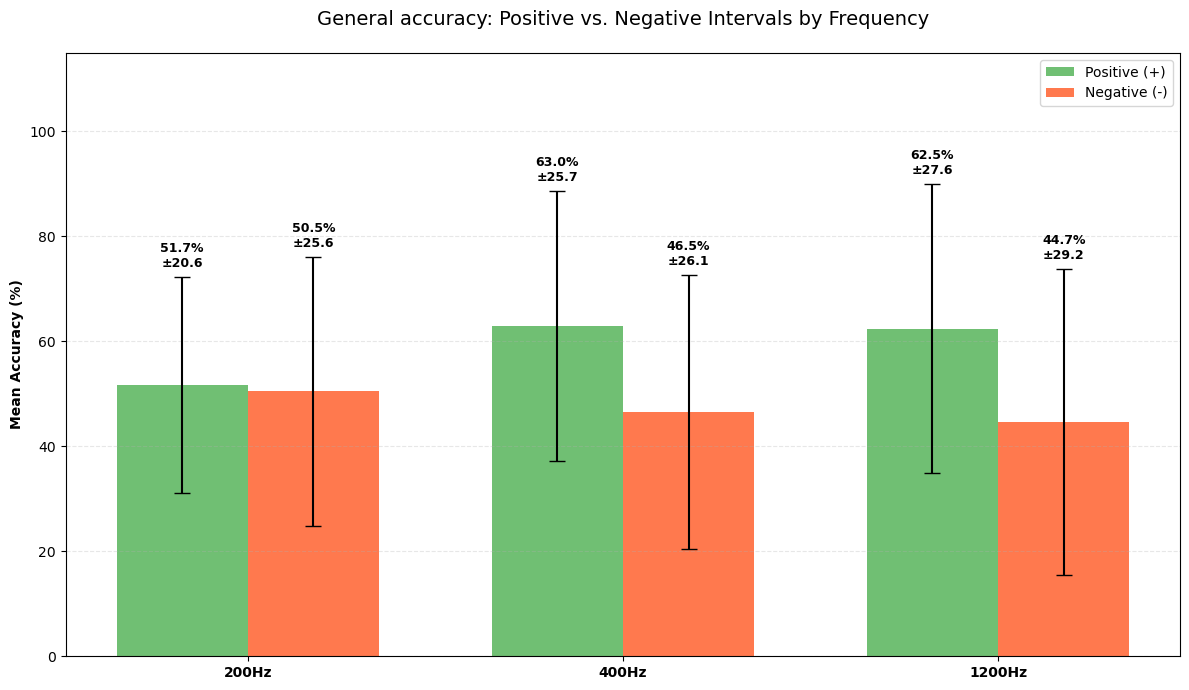

In [30]:
# 1. Prepare Data
# Assuming 'total_data' is your loaded DataFrame from the CSV
test_cols = [c for c in total_data.columns if c.startswith("(+)") or c.startswith("(-)")]
frequencies = ['200', '400', '1200']

def get_acc(row, cols):
    if not cols: return 0
    # Note: Dataset uses 'Acending' (typo included to match your data)
    correct = sum(1 for col in cols if row[col] == ("Acending" if "+" in col else "Descending"))
    return (correct / len(cols)) * 100

results = []
for freq in frequencies:
    for direction, prefix in [('Positive (+)', '(+)'), ('Negative (-)', '(-)')]:
        cols = [c for c in test_cols if f" {freq} " in c and c.startswith(prefix)]
        acc_series = total_data.apply(lambda r: get_acc(r, cols), axis=1)
        results.append({
            'Frequency': f'{freq}Hz',
            'Direction': direction,
            'Accuracy': acc_series.mean(),
            'Std': acc_series.std()
        })

res_total_data = pd.DataFrame(results)

# 2. Plotting
fig, ax = plt.subplots(figsize=(12, 7))
labels = res_total_data['Frequency'].unique()
x = np.arange(len(labels))
width = 0.35

pos_data = res_total_data[res_total_data['Direction'] == 'Positive (+)']
neg_data = res_total_data[res_total_data['Direction'] == 'Negative (-)']

# Create Bars
rects1 = ax.bar(x - width/2, pos_data['Accuracy'], width, yerr=pos_data['Std'], 
                label='Positive (+)', capsize=6, color='#4CAF50', alpha=0.8)
rects2 = ax.bar(x + width/2, neg_data['Accuracy'], width, yerr=neg_data['Std'], 
                label='Negative (-)', capsize=6, color='#FF5722', alpha=0.8)

# Styling
ax.set_ylabel('Mean Accuracy (%)', fontweight='bold')
ax.set_title('General accuracy: Positive vs. Negative Intervals by Frequency', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.legend()
ax.set_ylim(0, 115) # Extra space for labels
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add Labels (%) and Deviation (±)
def add_labels(rects, stds):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        std = stds.iloc[i]
        ax.annotate(f'{height:.1f}%\n±{std:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height + std),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

add_labels(rects1, pos_data['Std'])
add_labels(rects2, neg_data['Std'])

plt.tight_layout()
plt.show()

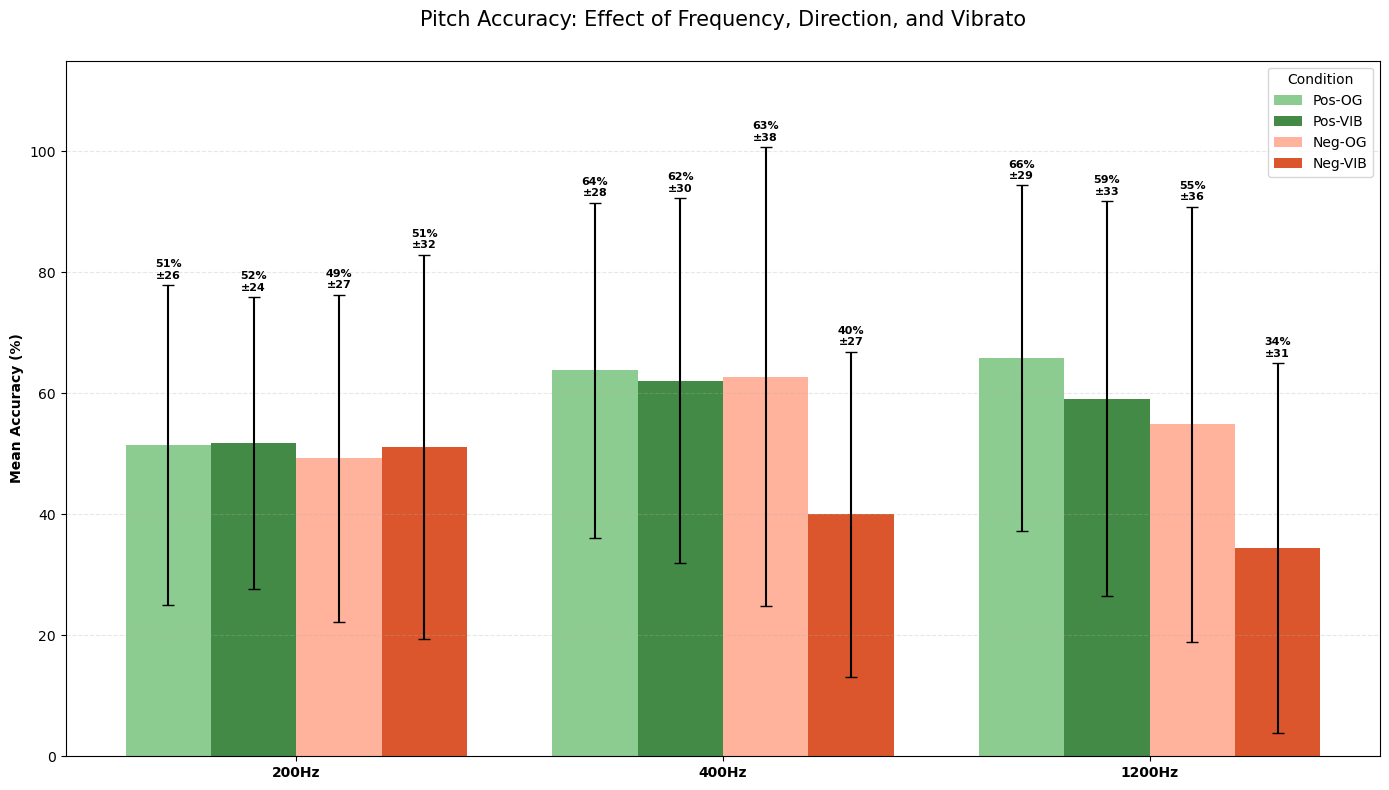

In [31]:
#Identify the test columns (starting with (+) or (-))
# These represent the pitch change tests (Positive = Ascending, Negative = Descending)
# 1. Identify test columns and categories
test_cols = [c for c in total_data.columns if c.startswith("(+)") or c.startswith("(-)")]
frequencies = ['200', '400', '1200']
tone_types = ['og', 'vib']
directions = [('Positive (+)', '(+)'), ('Negative (-)', '(-)')]

def get_acc(row, cols):
    if not cols: return 0
    # Note: Using 'Acending' to match dataset typo
    correct = sum(1 for col in cols if row[col] == ("Acending" if "+" in col else "Descending"))
    return (correct / len(cols)) * 100

# 2. Calculate mean and standard deviation for all 12 combinations
results = []
for freq in frequencies:
    for dir_name, dir_prefix in directions:
        for t_type in tone_types:
            # Filter columns by frequency, sign, and type (og/vib)
            cols = [c for c in test_cols if f" {freq} " in c and c.startswith(dir_prefix) and c.endswith(t_type)]
            acc_series = total_data.apply(lambda r: get_acc(r, cols), axis=1)
            results.append({
                'Freq': f'{freq}Hz', 'Dir': dir_name, 'Tone': t_type,
                'Acc': acc_series.mean(), 'Std': acc_series.std()
            })
res_total_data = pd.DataFrame(results)

# 3. Plotting the Grouped Bar Chart
labels = [f'{f}Hz' for f in frequencies]
x = np.arange(len(labels))
width = 0.2

# Define bar configurations (Direction, Tone, Color, Label)
configs = [
    ('Positive (+)', 'og', '#81C784', 'Pos-OG'),
    ('Positive (+)', 'vib', '#2E7D32', 'Pos-VIB'),
    ('Negative (-)', 'og', '#FFAB91', 'Neg-OG'),
    ('Negative (-)', 'vib', '#D84315', 'Neg-VIB')
]

fig, ax = plt.subplots(figsize=(14, 8))
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

for i, (dir_val, tone_val, color_val, label_val) in enumerate(configs):
    subset = res_total_data[(res_total_data['Dir'] == dir_val) & (res_total_data['Tone'] == tone_val)]
    rects = ax.bar(x + offsets[i], subset['Acc'], width, yerr=subset['Std'], 
                   label=label_val, color=color_val, capsize=4, alpha=0.9)
    
    # Add % and Deviation labels on top of bars
    for j, rect in enumerate(rects):
        height = rect.get_height()
        std = subset['Std'].iloc[j]
        ax.annotate(f'{height:.0f}%\n±{std:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height + std),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Mean Accuracy (%)', fontweight='bold')
ax.set_title('Pitch Accuracy: Effect of Frequency, Direction, and Vibrato', fontsize=15, pad=25)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.legend(title="Condition", bbox_to_anchor=(1, 1))
ax.set_ylim(0, 115)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

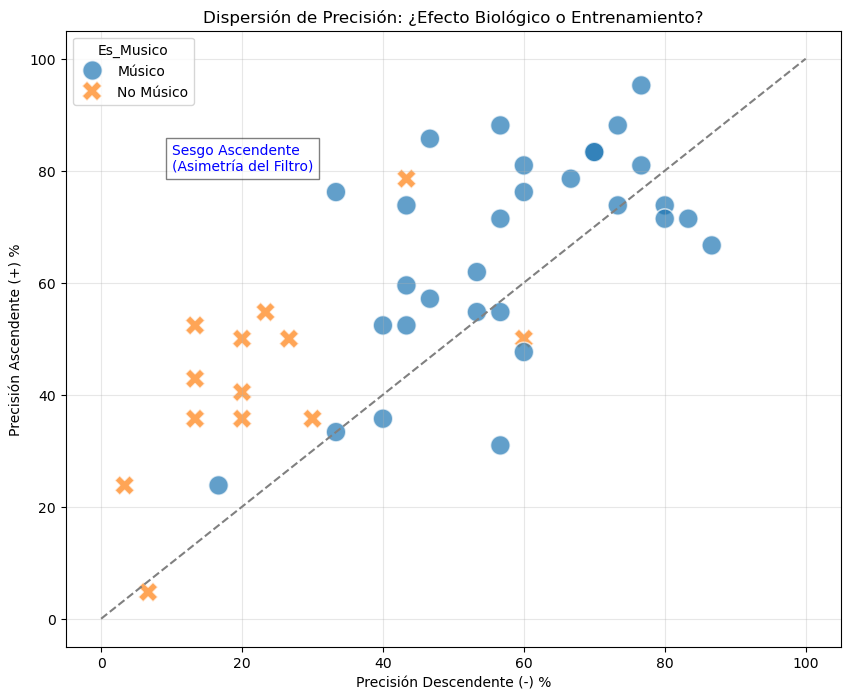

In [32]:
import seaborn as sns

# Calculamos precisión por dirección para cada fila
total_data['Acc_Pos'] = total_data[[c for c in test_cols if c.startswith("(+)")]].apply(lambda r: (r == "Acending").mean() * 100, axis=1)
total_data['Acc_Neg'] = total_data[[c for c in test_cols if c.startswith("(-)")]].apply(lambda r: (r == "Descending").mean() * 100, axis=1)
total_data['Es_Musico'] = total_data['MusicalTraining'].apply(lambda x: "Músico" if x != "No" else "No Músico")

# Configuración del gráfico
plt.figure(figsize=(10, 8))
sns.scatterplot(data=total_data, x='Acc_Neg', y='Acc_Pos', hue='Es_Musico', s=200, style='Es_Musico', alpha=0.7)

# Línea de Simetría
plt.plot([0, 100], [0, 100], color='gray', linestyle='--')

plt.title('Dispersión de Precisión: ¿Efecto Biológico o Entrenamiento?')
plt.xlabel('Precisión Descendente (-) %')
plt.ylabel('Precisión Ascendente (+) %')
plt.grid(True, alpha=0.3)

# Identificar la zona de asimetría biológica
plt.text(10, 80, "Sesgo Ascendente\n(Asimetría del Filtro)", color='blue', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

plt.show()

## Statistical tests (full suite)
This section runs assumption checks, repeated-measures ANOVA (if available),
pairwise paired tests with Holm correction, and an optional logistic GEE model.

In [38]:
from scipy import stats
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM


# ---- Build trial-level long format ----
def _parse_stim_col(col_name: str):
    col_stripped = col_name.strip()
    sign = '+' if col_stripped.startswith('(+)') else '-'
    parts = col_stripped.replace('(+)', '').replace('(-)', '').strip().split()
    cents = int(parts[0])
    freq = parts[1]
    tone = parts[2]  # 'og' or 'vib'
    direction = 'Positive' if sign == '+' else 'Negative'
    return cents, freq, tone, direction

records = []
for col in test_cols:
    cents, freq, tone, direction = _parse_stim_col(col)
    expected = "Acending" if col.strip().startswith("(+)") else "Descending"
    correct = (total_data[col] == expected).astype(int)
    for subject, val in correct.items():
        records.append({
            "subject": subject,
            "freq": freq,
            "tone": tone,
            "direction": direction,
            "correct": int(val)
        })

trial_long = pd.DataFrame(records)
cond_acc = (
    trial_long.groupby(["subject", "freq", "tone", "direction"])
    ["correct"].mean().reset_index()
)
cond_acc["acc"] = cond_acc["correct"] * 100

print("Trial-level rows:", len(trial_long))
print("Condition-level rows:", len(cond_acc))

# ---- Assumption checks ----
print("\n" + "=" * 60)
print("ASSUMPTION CHECKS")
print("=" * 60)

# Shapiro-Wilk per condition (skip if <3 samples)
shapiro_results = []
for (freq, tone, direction), group in cond_acc.groupby(["freq", "tone", "direction"]):
    data = group["acc"].dropna()
    if len(data) >= 3:
        w, p = stats.shapiro(data)
        shapiro_results.append({
            "freq": freq, "tone": tone, "direction": direction,
            "n": len(data), "W": w, "p": p
        })

shapiro_df = pd.DataFrame(shapiro_results).sort_values(["freq", "tone", "direction"])
display(shapiro_df)

# Levene tests (og vs vib, pos vs neg)
overall_tone = cond_acc.groupby(["subject", "tone"])["acc"].mean().unstack()
overall_dir = cond_acc.groupby(["subject", "direction"])["acc"].mean().unstack()

lev_og_vib = stats.levene(overall_tone["og"].dropna(), overall_tone["vib"].dropna())
lev_pos_neg = stats.levene(overall_dir["Positive"].dropna(), overall_dir["Negative"].dropna())
print(f"\nLevene og vs vib: W={lev_og_vib.statistic:.4f}, p={lev_og_vib.pvalue:.4f}")
print(f"Levene pos vs neg: W={lev_pos_neg.statistic:.4f}, p={lev_pos_neg.pvalue:.4f}")

# ---- Repeated-measures ANOVA (if statsmodels available) ----
print("\n" + "=" * 60)
print("REPEATED-MEASURES ANOVA")
print("=" * 60)
try:

    anova = AnovaRM(
        cond_acc, depvar="acc", subject="subject",
        within=["freq", "tone", "direction"]
    ).fit()
    print(anova)
except Exception as e:
    print("statsmodels not available or ANOVA failed:", e)

# ---- Paired tests + Holm correction ----
def cohens_dz(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

def paired_test(a, b, label):
    paired = pd.concat([a, b], axis=1).dropna()
    a = paired.iloc[:, 0]
    b = paired.iloc[:, 1]
    t = stats.ttest_rel(a, b)
    w = stats.wilcoxon(a, b, zero_method='wilcox', correction=False, alternative='two-sided', mode='approx')
    return {
        "comparison": label,
        "n": len(a),
        "t": t.statistic,
        "t_p": t.pvalue,
        "w": w.statistic,
        "w_p": w.pvalue,
        "dz": cohens_dz(a, b)
    }

def holm_adjust(pvals):
    pvals = np.asarray(pvals)
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty_like(pvals, dtype=float)
    for i, idx in enumerate(order):
        adj[idx] = min(1.0, (m - i) * pvals[idx])
    # ensure monotonicity
    for i in range(m - 2, -1, -1):
        adj[order[i]] = max(adj[order[i]], adj[order[i + 1]])
    return adj

results = []

# Overall og vs vib
og = cond_acc[cond_acc["tone"] == "og"].groupby("subject")["acc"].mean()
vib = cond_acc[cond_acc["tone"] == "vib"].groupby("subject")["acc"].mean()
results.append(paired_test(og, vib, "Overall: og vs vib"))

# Overall pos vs neg
pos = cond_acc[cond_acc["direction"] == "Positive"].groupby("subject")["acc"].mean()
neg = cond_acc[cond_acc["direction"] == "Negative"].groupby("subject")["acc"].mean()
results.append(paired_test(pos, neg, "Overall: positive vs negative"))

# Per frequency: og vs vib (averaged across direction)
for freq in sorted(cond_acc["freq"].unique(), key=lambda x: int(x)):
    og_f = cond_acc[(cond_acc["freq"] == freq) & (cond_acc["tone"] == "og")].groupby("subject")["acc"].mean()
    vib_f = cond_acc[(cond_acc["freq"] == freq) & (cond_acc["tone"] == "vib")].groupby("subject")["acc"].mean()
    results.append(paired_test(og_f, vib_f, f"{freq}Hz: og vs vib"))

# Per frequency: positive vs negative (averaged across tone)
for freq in sorted(cond_acc["freq"].unique(), key=lambda x: int(x)):
    pos_f = cond_acc[(cond_acc["freq"] == freq) & (cond_acc["direction"] == "Positive")].groupby("subject")["acc"].mean()
    neg_f = cond_acc[(cond_acc["freq"] == freq) & (cond_acc["direction"] == "Negative")].groupby("subject")["acc"].mean()
    results.append(paired_test(pos_f, neg_f, f"{freq}Hz: positive vs negative"))

# Per frequency x tone: positive vs negative
for freq in sorted(cond_acc["freq"].unique(), key=lambda x: int(x)):
    for tone in ["og", "vib"]:
        pos_ft = cond_acc[(cond_acc["freq"] == freq) & (cond_acc["tone"] == tone) & (cond_acc["direction"] == "Positive")].groupby("subject")["acc"].mean()
        neg_ft = cond_acc[(cond_acc["freq"] == freq) & (cond_acc["tone"] == tone) & (cond_acc["direction"] == "Negative")].groupby("subject")["acc"].mean()
        results.append(paired_test(pos_ft, neg_ft, f"{freq}Hz {tone}: positive vs negative"))

# Per frequency x direction: og vs vib
for freq in sorted(cond_acc["freq"].unique(), key=lambda x: int(x)):
    for direction in ["Positive", "Negative"]:
        og_fd = cond_acc[(cond_acc["freq"] == freq) & (cond_acc["tone"] == "og") & (cond_acc["direction"] == direction)].groupby("subject")["acc"].mean()
        vib_fd = cond_acc[(cond_acc["freq"] == freq) & (cond_acc["tone"] == "vib") & (cond_acc["direction"] == direction)].groupby("subject")["acc"].mean()
        results.append(paired_test(og_fd, vib_fd, f"{freq}Hz {direction}: og vs vib"))

results_df = pd.DataFrame(results)
results_df["t_p_holm"] = holm_adjust(results_df["t_p"].values)
results_df["w_p_holm"] = holm_adjust(results_df["w_p"].values)
display(results_df)

# ---- Optional: logistic GEE on trial-level data (requires statsmodels) ----
print("\n" + "=" * 60)
print("LOGISTIC GEE (OPTIONAL)")
print("=" * 60)
try:
   
    gee = smf.gee(
        "correct ~ C(freq) * C(tone) * C(direction)",
        groups="subject",
        data=trial_long,
        family=sm.families.Binomial()
    ).fit()
    print(gee.summary())
except Exception as e:
    print("statsmodels not available or GEE failed:", e)

Trial-level rows: 3096
Condition-level rows: 516

ASSUMPTION CHECKS


,freq,tone,direction,n,W,p
0,1200,og,Negative,43,0.883764,0.000417
1,1200,og,Positive,43,0.911234,0.002792
2,1200,vib,Negative,43,0.890279,0.000643
3,1200,vib,Positive,43,0.912971,0.003172
4,200,og,Negative,43,0.941679,0.029821
5,200,og,Positive,43,0.949586,0.057571
6,200,vib,Negative,43,0.918144,0.004662
7,200,vib,Positive,43,0.952154,0.071463
8,400,og,Negative,43,0.888972,0.000589
9,400,og,Positive,43,0.921479,0.006002



Levene og vs vib: W=0.0674, p=0.7958
Levene pos vs neg: W=0.5241, p=0.4711

REPEATED-MEASURES ANOVA
                      Anova
                    F Value Num DF  Den DF Pr > F
-------------------------------------------------
freq                 1.6150 2.0000 84.0000 0.2050
tone                 5.8067 1.0000 42.0000 0.0204
direction           22.3374 1.0000 42.0000 0.0000
freq:tone            8.0486 2.0000 84.0000 0.0006
freq:direction       5.1215 2.0000 84.0000 0.0080
tone:direction       5.1747 1.0000 42.0000 0.0281
freq:tone:direction  2.4395 2.0000 84.0000 0.0934



,comparison,n,t,t_p,w,w_p,dz,t_p_holm,w_p_holm
0,Overall: og vs vib,43,2.409719,0.020425,304.0,0.041273,0.367479,1.000000,1.000000
1,Overall: positive vs negative,43,4.726247,0.000026,138.0,0.000089,0.720746,1.000000,1.000000
2,200Hz: og vs vib,43,-0.358395,0.721843,407.5,0.765640,-0.054655,1.000000,1.000000
3,400Hz: og vs vib,43,2.286955,0.027304,232.5,0.027816,0.348757,1.000000,1.000000
4,1200Hz: og vs vib,43,3.943986,0.000298,158.0,0.001204,0.601452,1.000000,1.000000
5,200Hz: positive vs negative,43,0.279933,0.780903,418.0,0.675249,0.042689,1.000000,1.000000
6,400Hz: positive vs negative,43,4.438070,0.000064,148.0,0.000147,0.676799,1.000000,1.000000
7,1200Hz: positive vs negative,43,3.983648,0.000264,158.0,0.000413,0.607501,1.000000,1.000000
8,200Hz og: positive vs negative,43,0.482355,0.632058,445.0,0.735170,0.073558,1.000000,1.000000
9,200Hz vib: positive vs negative,43,0.037129,0.970558,466.0,0.932604,0.005662,0.970558,1.000000



LOGISTIC GEE (OPTIONAL)
                               GEE Regression Results                              
Dep. Variable:                     correct   No. Observations:                 3096
Model:                                 GEE   No. clusters:                       43
Method:                        Generalized   Min. cluster size:                  72
                      Estimating Equations   Max. cluster size:                  72
Family:                           Binomial   Mean cluster size:                72.0
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Mon, 23 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         18:39:45
                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------